# OVR-Ego4D Final Annotations Exploration

This notebook analyzes the final OVR annotations, verifies local media,
visualizes real repetition boundaries, and preserves the original synchronized
player, MP4 export, visual-exemplar generation, and Canva export workflow.


## 1. Setup

Place the notebook in the project root, next to `final_annotations/` and
`videos/`. Edit the paths below only if your layout differs.


In [1]:
from pathlib import Path
from urllib.parse import quote
import html
import json
import re
import uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SPLIT_ORDER = ["train", "val", "test"]
SPLIT_COLORS = {"train": "#2563eb", "val": "#f59e0b", "test": "#10b981"}
VIDEO_SUFFIXES = {".mp4", ".mkv", ".webm", ".mov", ".m4v", ".avi"}

In [2]:
ANNOTATIONS_DIR = Path("annotations")
VIDEO_ROOT = Path("videos")

print(f"OVR-Ego4D annotations: {ANNOTATIONS_DIR.resolve()}")
print(f"Videos:            {VIDEO_ROOT.resolve()}")


OVR-Ego4D annotations: /mnt/Workspace/audiovisual-video-repetition-counting/data/OVR-Ego4d/annotations
Videos:            /mnt/Workspace/audiovisual-video-repetition-counting/data/OVR-Ego4d/videos


## 2. Load and prepare annotations

The final CSVs already contain local video filenames, segment times and frames,
and the real `rep_N_start_frame` / `rep_N_end_frame` boundaries. No uniform
repetition boundaries are generated.


In [3]:
REQUIRED_COLUMNS = [
    "video_name",
    "count",
    "class",
    "fps",
    "repetition_segment_start_sec",
    "repetition_segment_end_sec",
    "repetition_segment_start_frame",
    "repetition_segment_end_frame",
]


def find_split_csv(directory, split):
    path = directory / f"ovr_ego4d_{split}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"Expected annotation CSV: {path}")
    return path


def extract_video_info(video_name):
    stem = Path(str(video_name)).stem
    parts = stem.rsplit("_", 2)
    if len(parts) != 3:
        return stem, np.nan, np.nan
    try:
        segment_start = float(parts[-2].replace("p", "."))
        segment_end = float(parts[-1].replace("p", "."))
    except ValueError:
        return stem, np.nan, np.nan
    return parts[0], segment_start, segment_end


def repetition_numbers(columns):
    numbers = set()
    names = set(map(str, columns))
    for name in names:
        match = re.fullmatch(r"rep_(\d+)_start_frame", name)
        if match and f"rep_{match.group(1)}_end_frame" in names:
            numbers.add(int(match.group(1)))
    return sorted(numbers)


datasets = {}
annotation_paths = {}
for split in SPLIT_ORDER:
    path = find_split_csv(ANNOTATIONS_DIR, split)
    frame = pd.read_csv(path).copy()

    missing = set(REQUIRED_COLUMNS) - set(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing columns: {', '.join(sorted(missing))}")

    rep_numbers = repetition_numbers(frame.columns)
    numeric_cols = [
        "count",
        "fps",
        "repetition_segment_start_sec",
        "repetition_segment_end_sec",
        "repetition_segment_start_frame",
        "repetition_segment_end_frame",
    ]
    for number in rep_numbers:
        numeric_cols.extend(
            [f"rep_{number}_start_frame", f"rep_{number}_end_frame"]
        )
    for column in numeric_cols:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    parsed = frame["video_name"].apply(extract_video_info)
    frame["video_id"] = parsed.apply(lambda item: item[0])
    frame["filename_segment_start_sec"] = parsed.apply(lambda item: item[1])
    frame["filename_segment_end_sec"] = parsed.apply(lambda item: item[2])
    frame["source_video_id"] = frame["video_id"].astype(str)
    frame["clip_stem"] = frame["video_name"].map(lambda value: Path(str(value)).stem)
    frame["split"] = split
    frame["row_in_split"] = np.arange(len(frame))

    # Compatibility columns used by the original player/export cells.
    frame["kinetics_start"] = 0.0
    frame["kinetics_end"] = np.nan
    frame["kinetics_duration_sec"] = np.nan
    frame["repetition_start"] = frame["repetition_segment_start_sec"]
    frame["repetition_end"] = frame["repetition_segment_end_sec"]
    frame["repetition_start_local_sec"] = frame["repetition_segment_start_sec"]
    frame["repetition_end_local_sec"] = frame["repetition_segment_end_sec"]
    frame["repetition_duration_sec"] = (
        frame["repetition_segment_end_sec"]
        - frame["repetition_segment_start_sec"]
    )
    frame["repetition_coverage"] = np.nan
    frame["mean_cycle_duration_sec"] = (
        frame["repetition_duration_sec"] / frame["count"]
    )

    def count_valid_repetitions(row):
        valid = 0
        for number in rep_numbers:
            start = row.get(f"rep_{number}_start_frame")
            end = row.get(f"rep_{number}_end_frame")
            if pd.notna(start) and pd.notna(end) and end > start:
                valid += 1
        return valid

    frame["annotated_repetition_pairs"] = frame.apply(
        count_valid_repetitions, axis=1
    )
    datasets[split] = frame
    annotation_paths[split] = path

annotations = pd.concat(datasets.values(), ignore_index=True, sort=False)
annotations["split"] = pd.Categorical(
    annotations["split"], SPLIT_ORDER, ordered=True
)
REPETITION_NUMBERS = repetition_numbers(annotations.columns)

print(
    f"Loaded {len(annotations):,} rows from "
    + ", ".join(path.name for path in annotation_paths.values())
)
print(
    "Detected repetition columns: "
    f"1–{max(REPETITION_NUMBERS, default=0)}"
)
display(annotations.head(3))


/tmp/ipykernel_2481688/1997630689.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["video_id"] = parsed.apply(lambda item: item[0])
/tmp/ipykernel_2481688/1997630689.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["filename_segment_start_sec"] = parsed.apply(lambda item: item[1])
/tmp/ipykernel_2481688/1997630689.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

Loaded 86,854 rows from ovr_ego4d_train.csv, ovr_ego4d_val.csv, ovr_ego4d_test.csv
Detected repetition columns: 1–71


/tmp/ipykernel_2481688/1997630689.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["annotated_repetition_pairs"] = frame.apply(


,video_name,count,class,description,fps,kinetics_start_sec,kinetics_end_sec,repetition_segment_start_sec,repetition_segment_end_sec,repetition_segment_start_frame,repetition_segment_end_frame,rep_1_start_frame,rep_1_end_frame,rep_2_start_frame,rep_2_end_frame,...,source_video_id,clip_stem,split,row_in_split,kinetics_start,kinetics_end,kinetics_duration_sec,repetition_start,repetition_end,repetition_start_local_sec,repetition_end_local_sec,repetition_duration_sec,repetition_coverage,mean_cycle_duration_sec,annotated_repetition_pairs
0,63932be6-4b53-4390-bf5b-1706282353f9_200.6190.mp4,5,unknown,A person is rotating the fish piece,30.000,0.000,10.000,6.330,8.200,190,246,190,201,201,212,...,63932be6-4b53-4390-bf5b-1706282353f9_200.6190,63932be6-4b53-4390-bf5b-1706282353f9_200.6190,train,0,0.000,NaN,NaN,6.330,8.200,6.330,8.200,1.870,NaN,0.374,5
1,494723eb-9670-4d7a-bb23-ecc66fd6e258_2491.1724...,2,unknown,A woman is making sweets,30.000,0.000,10.000,7.400,10.000,222,300,222,261,261,300,...,494723eb-9670-4d7a-bb23-ecc66fd6e258_2491.1724,494723eb-9670-4d7a-bb23-ecc66fd6e258_2491.1724,train,1,0.000,NaN,NaN,7.400,10.000,7.400,10.000,2.600,NaN,1.300,2
2,0a913608-709d-42d9-a90d-273caefdc153_594.9208.mp4,5,unknown,A person is playing the guitar,30.000,0.000,10.000,3.770,6.600,113,198,113,130,130,147,...,0a913608-709d-42d9-a90d-273caefdc153_594.9208,0a913608-709d-42d9-a90d-273caefdc153_594.9208,train,2,0.000,NaN,NaN,3.770,6.600,3.770,6.600,2.830,NaN,0.566,5


## 3. Dataset overview

The summary distinguishes annotation rows, local video files, action classes,
and the number of real annotated repetitions.


In [4]:
overview = (
    annotations.groupby("split", observed=True)
    .agg(
        annotation_rows=("video_name", "size"),
        unique_videos=("video_name", "nunique"),
        unique_classes=("class", "nunique"),
        annotated_repetitions=("count", "sum"),
        median_count=("count", "median"),
        maximum_count=("count", "max"),
        median_repetition_window_sec=("repetition_duration_sec", "median"),
        median_cycle_duration_sec=("mean_cycle_duration_sec", "median"),
    )
    .reindex(SPLIT_ORDER)
)

total = pd.DataFrame(
    {
        "annotation_rows": [len(annotations)],
        "unique_videos": [annotations["video_name"].nunique()],
        "unique_classes": [annotations["class"].nunique()],
        "annotated_repetitions": [annotations["count"].sum()],
        "median_count": [annotations["count"].median()],
        "maximum_count": [annotations["count"].max()],
        "median_repetition_window_sec": [annotations["repetition_duration_sec"].median()],
        "median_cycle_duration_sec": [annotations["mean_cycle_duration_sec"].median()],
    },
    index=["all"],
)
display(pd.concat([overview, total]).round(3))


,annotation_rows,unique_videos,unique_classes,annotated_repetitions,median_count,maximum_count,median_repetition_window_sec,median_cycle_duration_sec
train,61970,32538,1,291297,3.000,71,2.040,0.487
val,6865,6464,1,32577,4.000,61,2.040,0.486
test,18019,8580,1,85716,3.000,59,2.070,0.485
all,86854,41418,1,409590,3.000,71,2.060,0.486


### Annotation distributions

These plots show dataset size, repetition-count distribution, and annotated
repetition-window duration for each split.


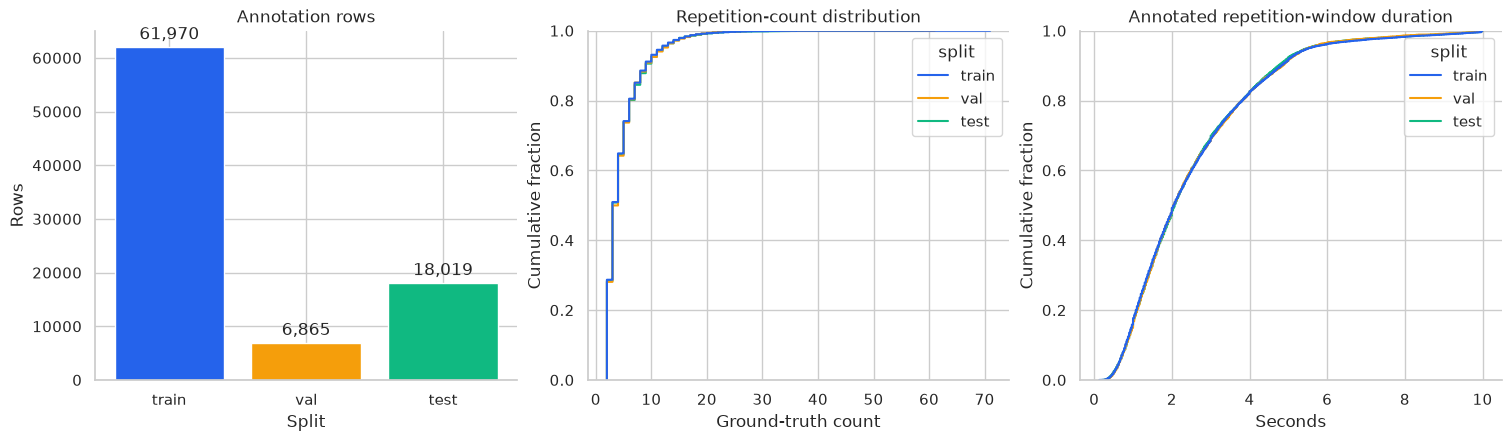

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

split_sizes = annotations["split"].value_counts(sort=False).reindex(SPLIT_ORDER)
axes[0].bar(
    split_sizes.index,
    split_sizes.values,
    color=[SPLIT_COLORS[split] for split in SPLIT_ORDER],
)
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}", padding=3)
axes[0].set(title="Annotation rows", xlabel="Split", ylabel="Rows")

sns.ecdfplot(
    data=annotations,
    x="count",
    hue="split",
    hue_order=SPLIT_ORDER,
    palette=SPLIT_COLORS,
    ax=axes[1],
)
axes[1].set(
    title="Repetition-count distribution",
    xlabel="Ground-truth count",
    ylabel="Cumulative fraction",
)

sns.ecdfplot(
    data=annotations,
    x="repetition_duration_sec",
    hue="split",
    hue_order=SPLIT_ORDER,
    palette=SPLIT_COLORS,
    ax=axes[2],
)
axes[2].set(
    title="Annotated repetition-window duration",
    xlabel="Seconds",
    ylabel="Cumulative fraction",
)
sns.despine()
plt.show()


## 4. Video inventory

Files are matched by the exact local filename stored in `video_name`.
Duplicate filenames found in different subdirectories are treated as ambiguous.


In [6]:
def build_media_index(root, suffixes):
    index = {}
    if not root.is_dir():
        return index
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in suffixes:
            index.setdefault(path.name, []).append(path)
    for paths in index.values():
        paths.sort()
    return index


video_index = build_media_index(VIDEO_ROOT, VIDEO_SUFFIXES)
inventory_rows = []
for video_name in sorted(annotations["video_name"].dropna().astype(str).unique()):
    matches = video_index.get(video_name, [])
    inventory_rows.append(
        {
            "video_name": video_name,
            "clip_stem": Path(video_name).stem,
            "video_path": matches[0] if len(matches) == 1 else None,
            "video_available": len(matches) == 1,
            "video_matches": len(matches),
        }
    )

media_inventory = pd.DataFrame(inventory_rows)
annotations_with_media = annotations.merge(
    media_inventory[["video_name", "video_path", "video_available", "video_matches"]],
    on="video_name",
    how="left",
)

video_overview = (
    annotations_with_media.groupby("split", observed=True)
    .agg(
        expected_videos=("video_name", "size"),
        videos_found=("video_available", "sum"),
        ambiguous_matches=("video_matches", lambda values: int((values > 1).sum())),
    )
    .reindex(SPLIT_ORDER)
)
video_overview["video_coverage"] = (
    video_overview["videos_found"] / video_overview["expected_videos"]
)
display(video_overview.round(3))


,expected_videos,videos_found,ambiguous_matches,video_coverage
split,,,,
train,61970,61970,0,1.000
val,6865,6865,0,1.000
test,18019,18019,0,1.000


## 5. Annotation and media checks

These checks cover segment validity, FPS/count validity, real repetition pairs,
frame/time agreement, duplicates, cross-split overlap, and missing media.


In [7]:
def row_repetition_pairs(row):
    pairs = []
    for number in REPETITION_NUMBERS:
        start = row.get(f"rep_{number}_start_frame")
        end = row.get(f"rep_{number}_end_frame")
        if pd.notna(start) or pd.notna(end):
            pairs.append((number, start, end))
    return pairs


invalid_rep_interval = []
reps_outside_segment = []
count_pair_mismatch = []
for _, row in annotations.iterrows():
    pairs = row_repetition_pairs(row)
    valid_pairs = [
        (number, start, end)
        for number, start, end in pairs
        if pd.notna(start) and pd.notna(end) and end > start
    ]
    invalid_rep_interval.append(
        any(pd.isna(start) or pd.isna(end) or end <= start for _, start, end in pairs)
    )
    segment_start = row["repetition_segment_start_frame"]
    segment_end = row["repetition_segment_end_frame"]
    reps_outside_segment.append(
        any(start < segment_start or end > segment_end for _, start, end in valid_pairs)
    )
    expected = int(round(row["count"])) if pd.notna(row["count"]) else -1
    count_pair_mismatch.append(len(valid_pairs) != expected)

invalid_rep_interval = pd.Series(invalid_rep_interval, index=annotations.index)
reps_outside_segment = pd.Series(reps_outside_segment, index=annotations.index)
count_pair_mismatch = pd.Series(count_pair_mismatch, index=annotations.index)
invalid_segment_seconds = (
    annotations["repetition_segment_end_sec"]
    <= annotations["repetition_segment_start_sec"]
)
invalid_segment_frames = (
    annotations["repetition_segment_end_frame"]
    <= annotations["repetition_segment_start_frame"]
)
invalid_count = annotations["count"].isna() | annotations["count"].le(0)
invalid_fps = annotations["fps"].isna() | annotations["fps"].le(0)

expected_start_frame = (
    annotations["repetition_segment_start_sec"] * annotations["fps"]
).round()
expected_end_frame = (
    annotations["repetition_segment_end_sec"] * annotations["fps"]
).round()
frame_time_mismatch = (
    (annotations["repetition_segment_start_frame"] - expected_start_frame).abs().gt(1)
    | (annotations["repetition_segment_end_frame"] - expected_end_frame).abs().gt(1)
)
clip_split_counts = annotations.groupby(
    "video_name",
    observed=True,
)["split"].nunique()

# Check every column present in the original CSV files.
source_columns = list(
    pd.read_csv(annotation_paths[SPLIT_ORDER[0]], nrows=0).columns
)

# Count all rows involved in exact duplicates.
exact_duplicate_mask = annotations[source_columns].duplicated(
    keep=False
)

checks = pd.DataFrame(
    {
        "diagnostic": [
            "Rows with missing required values",
            "Rows with invalid segment-second intervals",
            "Rows with invalid segment-frame intervals",
            "Rows with non-positive counts",
            "Rows with non-positive FPS",
            "Segment seconds/frames disagree by more than one frame",
            "Incomplete or invalid repetition-frame pairs",
            "Repetition pairs outside the annotated segment",
            "Valid repetition-pair count differs from count",
            "Exact duplicate annotation rows",
            "Videos present in multiple splits",
            "Expected videos missing or ambiguous",
        ],
        "affected": [
            int(annotations[REQUIRED_COLUMNS].isna().any(axis=1).sum()),
            int(invalid_segment_seconds.sum()),
            int(invalid_segment_frames.sum()),
            int(invalid_count.sum()),
            int(invalid_fps.sum()),
            int(frame_time_mismatch.sum()),
            int(invalid_rep_interval.sum()),
            int(reps_outside_segment.sum()),
            int(count_pair_mismatch.sum()),
            int(exact_duplicate_mask.sum()),
            int(clip_split_counts.gt(1).sum()),
            int(
                (~annotations_with_media["video_available"].fillna(False)).sum()
            ),
        ],
    }
)

display(checks)



,diagnostic,affected
0,Rows with missing required values,0
1,Rows with invalid segment-second intervals,0
2,Rows with invalid segment-frame intervals,0
3,Rows with non-positive counts,0
4,Rows with non-positive FPS,0
5,Segment seconds/frames disagree by more than o...,0
6,Incomplete or invalid repetition-frame pairs,0
7,Repetition pairs outside the annotated segment,0
8,Valid repetition-pair count differs from count,0
9,Exact duplicate annotation rows,0


In [8]:
# Assign a group number to each set of identical annotation rows
duplicate_group_ids = annotations.groupby(
    source_columns,
    dropna=False,
    sort=False,
).ngroup()

duplicate_examples = annotations.loc[
    exact_duplicate_mask,
    ["split", "row_in_split", *source_columns],
].copy()

duplicate_examples.insert(
    0,
    "duplicate_group",
    duplicate_group_ids.loc[exact_duplicate_mask].to_numpy(),
)

duplicate_examples["group_size"] = duplicate_examples.groupby(
    "duplicate_group"
)["duplicate_group"].transform("size")

duplicate_examples = duplicate_examples.sort_values(
    ["duplicate_group", "split", "row_in_split"]
)

if duplicate_examples.empty:
    print("No exact duplicate rows found.")
else:
    display(duplicate_examples.head(20))

No exact duplicate rows found.


## 6. Select examples

The table selects low-, median-, and high-count OVR annotations from each split.


In [9]:
annotations_with_media = annotations.merge(
    media_inventory[
        ["clip_stem", "video_available", "video_path"]
    ],
    on="clip_stem",
    how="left",
)

example_rows = []
for split in SPLIT_ORDER:
    split_frame = annotations_with_media.loc[
        annotations_with_media["split"].eq(split)
    ].copy()
    complete = split_frame.loc[
        split_frame["video_available"]
    ]
    candidates = complete if len(complete) else split_frame
    candidates = candidates.sort_values("count")
    if not len(candidates):
        continue
    positions = {
        "low count": 0,
        "median count": len(candidates) // 2,
        "high count": len(candidates) - 1,
    }
    for label, position in positions.items():
        row = candidates.iloc[position]
        example_rows.append(
            {
                "split": split,
                "selection": label,
                "row_in_split": int(row["row_in_split"]),
                "clip_stem": row["clip_stem"],
                "count": row["count"],
                "repetition_window_sec": row["repetition_duration_sec"],
                "video": bool(row["video_available"]),
            }
        )

examples = pd.DataFrame(example_rows)
display(examples)

,split,selection,row_in_split,clip_stem,count,repetition_window_sec,video
0,train,low count,34,c82e03e6-291d-4877-8a40-6b5db3f0292d_331.8026,2,1.700,True
1,train,median count,30981,146a4b4b-96a5-4d8f-a5b1-78dbb6ee5edf_10153.3220,3,1.300,True
2,train,high count,31199,cd087f89-9c3e-4224-a11c-3fa89405d057_248.5638,71,9.970,True
3,val,low count,1531,4f9f782c-6bee-467e-9c7e-cb7a64d7027d_267.1679,2,0.900,True
4,val,median count,14,603ba92d-083e-438d-9918-5fe4cb2ecef5_1157.6422,4,1.870,True
5,val,high count,2594,25879c6c-48aa-41d0-82b0-cddb90952cd4_75.5485,61,9.970,True
6,test,low count,18006,a5a41fe3-d5db-4c53-b821-c8437197a774_37.1364,2,1.440,True
7,test,median count,9306,504315c0-17fd-4259-9d2c-fd2b25fdcbea_379.1425,3,0.930,True
8,test,high count,17614,79b407c2-a651-40f7-a0ed-cf4819e92352_1820.7240,59,5.970,True


## 7. Synchronized video and annotation


In [10]:
def get_annotation_row(split="train", row_number=0):
    frame = annotations_with_media.loc[
        annotations_with_media["split"].eq(split)
    ]
    if not 0 <= row_number < len(frame):
        raise IndexError(
            f"row_number must be between 0 and {len(frame) - 1} for {split}."
        )
    return frame.iloc[row_number]


def notebook_relative_url(path):
    try:
        relative = Path(path).resolve().relative_to(Path.cwd().resolve())
    except ValueError:
        return None
    return quote(relative.as_posix(), safe="/")


def finite_float(value, default):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return default
    return number if np.isfinite(number) else default


def show_ovr_ego4d_example(split="train", row_number=0):
    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    if not isinstance(video_path, Path) or not video_path.is_file():
        print(f"Video not found for {row['video_name']}")
        return

    video_url = notebook_relative_url(video_path)
    if video_url is None:
        print("The video is outside the Jupyter server root.")
        print("Start Jupyter from the project root or one of its parents.")
        return

    fps = finite_float(row.get("fps"), 0.0)
    kinetics_end = finite_float(row.get("kinetics_end_sec"), 0.0)
    repetition_start = max(
        0.0,
        finite_float(
            row.get(
                "repetition_segment_start_sec",
                row.get("repetition_start_local_sec", 0.0),
            ),
            0.0,
        ),
    )
    repetition_end = max(
        repetition_start,
        finite_float(
            row.get(
                "repetition_segment_end_sec",
                row.get("repetition_end_local_sec", repetition_start),
            ),
            repetition_start,
        ),
    )

    # The browser replaces this fallback with the exact media duration.
    duration = max(kinetics_end, repetition_end, 0.001)
    window_left = 100 * repetition_start / duration
    window_width = 100 * (repetition_end - repetition_start) / duration

    action_class = str(row.get("class", "unknown"))
    description_value = row.get("description", "")
    description = (
        ""
        if pd.isna(description_value)
        else str(description_value)
    )
    video_filename = str(row.get("video_name", video_path.name))
    count_val = int(round(finite_float(row.get("count"), 0.0)))

    repetition_blocks_html = ""
    if count_val > 0 and fps > 0:
        for i in range(1, count_val + 1):
            frame_pair = None
            for start_frame_key, end_frame_key in (
                (f"rep_{i}_start_frame", f"rep_{i}_end_frame"),
                (f"rep_start_frame_{i}", f"rep_end_frame_{i}"),
            ):
                if (
                    start_frame_key in row
                    and end_frame_key in row
                    and pd.notna(row[start_frame_key])
                    and pd.notna(row[end_frame_key])
                ):
                    frame_pair = (
                        float(row[start_frame_key]),
                        float(row[end_frame_key]),
                    )
                    break

            if frame_pair is None:
                continue

            f_start, f_end = frame_pair
            rep_s = max(0.0, f_start / fps)
            rep_e = max(rep_s, f_end / fps)
            rep_left = max(0.0, 100 * rep_s / duration)
            rep_width = max(0.0, 100 * (rep_e - rep_s) / duration)
            repetition_blocks_html += f'''
              <div class="single-repetition" data-start="{rep_s:.9f}"
                   data-end="{rep_e:.9f}"
                   style="left:{rep_left:.4f}%; width:{rep_width:.4f}%;"
                   title="Rep {i}">
                <span>{i}</span>
              </div>
            '''

    uid = f"ovr-ego4d-{uuid.uuid4().hex}"
    player = f'''
    <div id="{uid}" class="ovr-ego4d-player" data-duration="{duration:.9f}"
         data-repetition-start="{repetition_start:.9f}"
         data-repetition-end="{repetition_end:.9f}">
      <style>
        #{uid} {{ max-width:1000px; font-family:system-ui,sans-serif; color:#f8fafc; background:#1e293b; padding:16px; border-radius:12px; box-shadow:0 4px 6px -1px rgba(0,0,0,.1); }}
        #{uid} .meta {{ display:flex; flex-wrap:wrap; gap:10px 20px; margin:0 0 12px; font-size:14px; background:#0f172a; padding:10px 14px; border-radius:8px; border:1px solid #334155; }}
        #{uid} .meta span {{ color:#e2e8f0; }}
        #{uid} .meta strong {{ font-weight:600; color:#38bdf8; }}
        #{uid} .meta .description {{ flex:1 1 100%; }}
        #{uid} video {{ display:block; width:100%; max-height:560px; background:#000; border-radius:8px; }}
        #{uid} .track-label {{ margin-top:12px; color:#cbd5e1; font-size:13px; font-weight:600; }}
        #{uid} .timeline {{ position:relative; height:42px; margin-top:4px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} .repetition-window {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; display:flex; align-items:center; justify-content:center; overflow:hidden; background:rgba(245,158,11,.2); border-left:1px dashed #f59e0b; border-right:1px dashed #f59e0b; }}
        #{uid} .single-repetition {{ position:absolute; top:2px; bottom:2px; background:#f59e0b; border:1px solid #b45309; border-radius:3px; display:flex; align-items:center; justify-content:center; box-sizing:border-box; }}
        #{uid} .single-repetition span {{ color:#0f172a; font-size:10px; font-weight:700; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; padding:0 2px; }}
        #{uid} .timeline-playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .axis {{ display:flex; justify-content:space-between; margin-top:4px; color:#94a3b8; font-size:12px; }}
        #{uid} .status {{ margin-top:6px; color:#e2e8f0; font-size:13px; min-height:20px; font-weight:500; }}
      </style>

      <div class="meta">
        <span><strong>Video File:</strong> {html.escape(video_filename)}</span>
        <span><strong>Action Class:</strong> {html.escape(action_class)}</span>
        <span><strong>Split:</strong> {html.escape(str(row['split']))}</span>
        <span><strong>Count:</strong> {float(row['count']):g}</span>
        <span><strong>FPS:</strong> {fps:g}</span>
        <span><strong>Video Duration:</strong> <span class="video-duration">loading…</span></span>
        <span><strong>Repetition Window:</strong> {repetition_start:.3f}–{repetition_end:.3f} s</span>
        <span class="description"><strong>Description:</strong> {html.escape(description)}</span>
      </div>

      <video controls preload="metadata" src="{video_url}"></video>

      <div class="track-label">Annotated repetitions breakdown</div>
      <div class="timeline" role="slider" aria-label="Annotated repetition timeline"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <div class="repetition-window"></div>
        {repetition_blocks_html}
        <div class="timeline-playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="status" aria-live="polite">0.000 s · before the annotated window</div>

      <script>
        (() => {{
          const root = document.getElementById({json.dumps(uid)});
          const video = root.querySelector('video');
          const timeline = root.querySelector('.timeline');
          const timelinePlayhead = root.querySelector('.timeline-playhead');
          const repetitionWindow = root.querySelector('.repetition-window');
          const repetitionBlocks = root.querySelectorAll('.single-repetition');
          const axisEnds = root.querySelectorAll('.axis-end');
          const durationLabels = root.querySelectorAll('.video-duration');
          const status = root.querySelector('.status');
          let duration = Number(root.dataset.duration);
          const repetitionStart = Number(root.dataset.repetitionStart);
          const repetitionEnd = Number(root.dataset.repetitionEnd);
          let animationFrame = null;

          const layoutRange = (element, start, end) => {{
            if (!Number.isFinite(duration) || duration <= 0) return;
            const safeStart = Math.min(Math.max(start, 0), duration);
            const safeEnd = Math.min(Math.max(end, safeStart), duration);
            element.style.left = `${{100 * safeStart / duration}}%`;
            element.style.width = `${{100 * (safeEnd - safeStart) / duration}}%`;
          }};

          const layoutTracks = () => {{
            layoutRange(repetitionWindow, repetitionStart, repetitionEnd);
            repetitionBlocks.forEach(block => {{
              layoutRange(
                block,
                Number(block.dataset.start),
                Number(block.dataset.end)
              );
            }});
            timeline.setAttribute('aria-valuemax', duration.toFixed(3));
            axisEnds.forEach(label => {{
              label.textContent = `${{duration.toFixed(3)}} s`;
            }});
            durationLabels.forEach(label => {{
              label.textContent = `${{duration.toFixed(3)}} s`;
            }});
          }};

          const useVideoDuration = () => {{
            const measuredDuration = Number(video.duration);
            if (Number.isFinite(measuredDuration) && measuredDuration > 0) {{
              duration = measuredDuration;
              root.dataset.duration = measuredDuration.toFixed(9);
              layoutTracks();
            }}
          }};

          const update = () => {{
            const t = Math.min(Math.max(video.currentTime || 0, 0), duration);
            timelinePlayhead.style.left = `${{100 * t / duration}}%`;
            timeline.setAttribute('aria-valuenow', t.toFixed(3));
            if (t < repetitionStart) {{
              status.textContent = `${{t.toFixed(3)}} s · before the annotated window`;
            }} else if (t <= repetitionEnd) {{
              status.textContent = `${{t.toFixed(3)}} s · inside the annotated window`;
            }} else {{
              status.textContent = `${{t.toFixed(3)}} s · after the annotated window`;
            }}
          }};

          const animate = () => {{
            update();
            if (!video.paused && !video.ended) {{
              animationFrame = requestAnimationFrame(animate);
            }}
          }};

          const seekFromTrack = event => {{
            const bounds = timeline.getBoundingClientRect();
            if (bounds.width <= 0) return;
            video.currentTime = duration * (event.clientX - bounds.left) / bounds.width;
            update();
          }};

          timeline.addEventListener('click', seekFromTrack);
          video.addEventListener('play', () => {{
            if (animationFrame !== null) cancelAnimationFrame(animationFrame);
            animate();
          }});
          video.addEventListener('pause', update);
          video.addEventListener('ended', update);
          video.addEventListener('seeked', update);
          video.addEventListener('loadedmetadata', () => {{
            useVideoDuration();
            update();
          }});

          layoutTracks();
          if (video.readyState >= 1) useVideoDuration();
          update();
        }})();
      </script>
    </div>
    '''
    display(HTML(player))

`EXAMPLE_ROW` refers to the original row order within the selected OVR-Ego4D split.
The browser must be able to serve both the notebook and media files from the
same Jupyter root.


In [11]:
# Change these two values to inspect another annotation row.
EXAMPLE_SPLIT = "train"
EXAMPLE_ROW = 1950

show_ovr_ego4d_example(EXAMPLE_SPLIT, EXAMPLE_ROW)


In [12]:
from pathlib import Path

import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display


EXPORT_OVR_EGO4D_MP4 = True
OVR_EGO4D_EXPORT_DIR = Path("canva_exports")


def export_ovr_ego4d_example_mp4(
    split=EXAMPLE_SPLIT,
    row_number=EXAMPLE_ROW,
    output_dir=OVR_EGO4D_EXPORT_DIR,
    output_fps=24,
    output_width=1280,
    video_height=720,
    panel_height=170,
    crf=23,
):
    """Export the selected OVR-Ego4D example with its repetition timeline."""

    def probe_duration(path, ffprobe_executable):
        result = subprocess.run(
            [
                ffprobe_executable,
                "-v",
                "error",
                "-show_entries",
                "format=duration",
                "-of",
                "default=noprint_wrappers=1:nokey=1",
                str(path),
            ],
            capture_output=True,
            text=True,
            check=False,
        )
        if result.returncode != 0:
            return float("nan")
        try:
            duration_value = float(result.stdout.strip())
        except (TypeError, ValueError):
            return float("nan")
        return (
            duration_value
            if np.isfinite(duration_value) and duration_value > 0
            else float("nan")
        )

    def finite_float(value, default=float("nan")):
        try:
            result = float(value)
        except (TypeError, ValueError):
            return default
        return result if np.isfinite(result) else default

    def first_finite(row, names, default=float("nan")):
        for name in names:
            if name in row:
                value = finite_float(row.get(name))
                if np.isfinite(value):
                    return value
        return default

    def repetition_frame_pair(row, repetition_index):
        alternatives = (
            (
                f"rep_start_frame_{repetition_index}",
                f"rep_end_frame_{repetition_index}",
            ),
            (
                f"rep_{repetition_index}_start_frame",
                f"rep_{repetition_index}_end_frame",
            ),
        )
        for start_name, end_name in alternatives:
            start_frame = finite_float(row.get(start_name))
            end_frame = finite_float(row.get(end_name))
            if np.isfinite(start_frame) and np.isfinite(end_frame):
                return start_frame, end_frame
        return None

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if ffmpeg is None or ffprobe is None:
        raise RuntimeError("FFmpeg and FFprobe must be available in PATH.")
    if output_fps <= 0 or output_width <= 0 or video_height <= 0 or panel_height <= 0:
        raise ValueError("Output dimensions and output_fps must be positive.")

    row = get_annotation_row(split, row_number)
    video_value = row.get("video_path")
    video_path = Path(video_value) if video_value is not None else None
    if video_path is None or not video_path.is_file():
        raise FileNotFoundError(
            f"Video not found for row {row_number} in split {split!r}."
        )

    duration = probe_duration(video_path, ffprobe)
    if not np.isfinite(duration):
        kinetics_start = first_finite(row, ("kinetics_start_sec",), default=0.0)
        kinetics_end = first_finite(row, ("kinetics_end_sec",))
        if np.isfinite(kinetics_end) and kinetics_end > kinetics_start:
            duration = kinetics_end - kinetics_start
    if not np.isfinite(duration):
        duration = finite_float(row.get("kinetics_duration_sec"))
    if not np.isfinite(duration) or duration <= 0:
        raise ValueError(f"Cannot determine a valid duration for {video_path.name}.")

    repetition_start = first_finite(
        row,
        ("repetition_segment_start_sec", "repetition_start_local_sec"),
        default=0.0,
    )
    repetition_end = first_finite(
        row,
        ("repetition_segment_end_sec", "repetition_end_local_sec"),
        default=duration,
    )
    repetition_start = float(np.clip(repetition_start, 0.0, duration))
    repetition_end = float(np.clip(repetition_end, repetition_start, duration))

    count_value = max(0, int(round(finite_float(row.get("count"), 0.0))))
    metadata_fps = finite_float(row.get("fps"), 0.0)

    repetition_intervals = []
    if count_value > 0 and metadata_fps > 0:
        for repetition_index in range(1, count_value + 1):
            frame_pair = repetition_frame_pair(row, repetition_index)
            if frame_pair is None:
                continue

            start_frame, end_frame = frame_pair
            interval_start = start_frame / metadata_fps
            interval_end = end_frame / metadata_fps
            interval_start = float(np.clip(interval_start, 0.0, duration))
            interval_end = float(np.clip(interval_end, interval_start, duration))
            if interval_end > interval_start:
                repetition_intervals.append(
                    (repetition_index, interval_start, interval_end)
                )

    clip_stem = str(row.get("clip_stem") or video_path.stem)
    action_class = str(row.get("class") or "unknown")

    description_value = row.get("description")
    description = "" if description_value is None else str(description_value).strip()
    if description.lower() == "nan":
        description = ""
    description_label = description or "Not available"
    if len(description_label) > 180:
        description_label = f"{description_label[:177]}..."

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{clip_stem}_ego4d_annotated.mp4"

    # Geometry of the timeline panel appended below the video.
    track_left_px = 40
    track_right_px = 40
    track_width_px = output_width - track_left_px - track_right_px
    timeline_top_px = 60
    timeline_height_px = 54

    with tempfile.TemporaryDirectory(prefix="ovr_ego4d_export_") as temp_dir:
        panel_path = Path(temp_dir) / "timeline.png"

        figure = plt.figure(
            figsize=(output_width / 100, panel_height / 100),
            dpi=100,
            facecolor="#1e293b",
        )
        timeline_axis = figure.add_axes(
            [
                track_left_px / output_width,
                (panel_height - timeline_top_px - timeline_height_px) / panel_height,
                track_width_px / output_width,
                timeline_height_px / panel_height,
            ]
        )
        timeline_axis.set_facecolor("#334155")
        timeline_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.20,
            linewidth=0,
        )
        timeline_axis.axvline(
            repetition_start,
            color="#f59e0b",
            linewidth=1.5,
            linestyle="--",
        )
        timeline_axis.axvline(
            repetition_end,
            color="#f59e0b",
            linewidth=1.5,
            linestyle="--",
        )

        for repetition_index, interval_start, interval_end in repetition_intervals:
            timeline_axis.axvspan(
                interval_start,
                interval_end,
                ymin=0.06,
                ymax=0.94,
                facecolor="#f59e0b",
                edgecolor="#b45309",
                linewidth=1,
                alpha=1.0,
            )
            timeline_axis.text(
                (interval_start + interval_end) / 2,
                0.5,
                str(repetition_index),
                ha="center",
                va="center",
                color="#0f172a",
                fontsize=10,
                fontweight="bold",
                clip_on=True,
            )

        timeline_axis.set(xlim=(0, duration), ylim=(0, 1), xticks=[], yticks=[])
        for spine in timeline_axis.spines.values():
            spine.set_visible(False)

        left_x = track_left_px / output_width
        right_x = (track_left_px + track_width_px) / output_width
        figure.text(
            left_x,
            0.83,
            f"Annotated repetitions | class: {action_class} | count: {count_value}",
            color="#cbd5e1",
            fontsize=10,
            fontweight="bold",
        )
        figure.text(
            left_x,
            0.70,
            f"Description: {description_label}",
            color="#94a3b8",
            fontsize=9,
        )
        figure.text(left_x, 0.18, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            right_x,
            0.18,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.text(
            left_x,
            0.04,
            f"Annotated window: {repetition_start:.3f}–{repetition_end:.3f} s",
            color="#94a3b8",
            fontsize=9,
        )
        figure.savefig(
            panel_path,
            dpi=100,
            facecolor=figure.get_facecolor(),
            edgecolor="none",
        )
        plt.close(figure)

        cursor_x = (
            f"{float(track_left_px):.1f}"
            f"+(t/{duration:.9f})*{float(track_width_px):.1f}"
        )
        cursor_y = video_height + timeline_top_px
        filter_graph = (
            f"[0:v]trim=duration={duration:.9f},setpts=PTS-STARTPTS,"
            f"fps={int(output_fps)},"
            f"scale={output_width}:{video_height}:force_original_aspect_ratio=decrease,"
            f"pad={output_width}:{video_height}:(ow-iw)/2:(oh-ih)/2:color=0x0b1020,"
            "format=yuv420p[video];"
            f"[1:v]setpts=PTS-STARTPTS,fps={int(output_fps)},"
            f"scale={output_width}:{panel_height},format=yuv420p[panel];"
            "[video][panel]vstack=inputs=2:shortest=1[base];"
            f"color=c=0xef4444:s=4x{timeline_height_px}:"
            f"r={int(output_fps)}:d={duration:.9f}[cursor];"
            f"[base][cursor]overlay=x='{cursor_x}':y={cursor_y}:shortest=1[outv]"
        )

        command = [
            ffmpeg,
            "-y",
            "-i",
            str(video_path),
            "-loop",
            "1",
            "-framerate",
            str(int(output_fps)),
            "-i",
            str(panel_path),
            "-filter_complex",
            filter_graph,
            "-map",
            "[outv]",
            "-an",
            "-t",
            f"{duration:.9f}",
            "-r",
            str(int(output_fps)),
            "-c:v",
            "libx264",
            "-preset",
            "fast",
            "-crf",
            str(int(crf)),
            "-pix_fmt",
            "yuv420p",
            "-movflags",
            "+faststart",
            str(output_path),
        ]
        result = subprocess.run(command, capture_output=True, text=True, check=False)
        if result.returncode != 0:
            raise RuntimeError("FFmpeg export failed:\n" + result.stderr[-5000:])

    print(f"Saved MP4: {output_path.resolve()}")
    return output_path


if EXPORT_OVR_EGO4D_MP4:
    OVR_EGO4D_MP4_PATH = export_ovr_ego4d_example_mp4()
    display(Video(filename=str(OVR_EGO4D_MP4_PATH), embed=False, html_attributes="controls"))
else:
    print("Set EXPORT_OVR_EGO4D_MP4 = True and run this cell to create the MP4.")

Saved MP4: /mnt/Workspace/audiovisual-video-repetition-counting/data/OVR-Ego4d/canva_exports/38245bd9-df0e-4746-a0be-f0ca08f42932_559.7149_ego4d_annotated.mp4


In [13]:
import wave

OVR_EGO4D_AUDIO_ROOT = Path("audios")


def get_annotation_row(split="train", row_number=0):
    frame = annotations_with_media.loc[annotations_with_media["split"].eq(split)]
    if not 0 <= row_number < len(frame):
        raise IndexError(
            f"row_number must be between 0 and {len(frame) - 1} for {split}."
        )
    return frame.iloc[row_number]


def notebook_relative_url(path):
    try:
        relative = Path(path).resolve().relative_to(Path.cwd().resolve())
    except ValueError:
        return None
    return quote(relative.as_posix(), safe="/")


def wav_duration_seconds(path):
    with wave.open(str(path), "rb") as handle:
        sample_rate = handle.getframerate()
        frame_count = handle.getnframes()
    if sample_rate <= 0:
        raise ValueError("WAV sample rate is unavailable")
    return frame_count / sample_rate


def read_waveform_envelope(path, max_bins=900):
    with wave.open(str(path), "rb") as handle:
        channels = handle.getnchannels()
        sample_width = handle.getsampwidth()
        frame_count = handle.getnframes()
        raw = handle.readframes(frame_count)

    if sample_width == 1:
        samples = np.frombuffer(raw, dtype=np.uint8).astype(np.float32) - 128
    elif sample_width == 2:
        samples = np.frombuffer(raw, dtype="<i2").astype(np.float32)
    elif sample_width == 3:
        bytes_ = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 3)
        values = (
            bytes_[:, 0].astype(np.int32)
            | (bytes_[:, 1].astype(np.int32) << 8)
            | (bytes_[:, 2].astype(np.int32) << 16)
        )
        values = np.where(values & 0x800000, values - 0x1000000, values)
        samples = values.astype(np.float32)
    elif sample_width == 4:
        samples = np.frombuffer(raw, dtype="<i4").astype(np.float32)
    else:
        raise ValueError(f"Unsupported WAV sample width: {sample_width} bytes")

    if channels > 1:
        samples = samples.reshape(-1, channels).mean(axis=1)
    if not len(samples):
        return np.array([0.0]), np.array([0.0])
    peak = float(np.max(np.abs(samples)))
    if peak > 0:
        samples = samples / peak

    bin_count = min(max_bins, len(samples))
    edges = np.linspace(0, len(samples), bin_count + 1, dtype=int)
    minima = np.empty(bin_count, dtype=float)
    maxima = np.empty(bin_count, dtype=float)
    for index in range(bin_count):
        chunk = samples[edges[index] : edges[index + 1]]
        minima[index] = chunk.min() if len(chunk) else 0.0
        maxima[index] = chunk.max() if len(chunk) else 0.0
    return minima, maxima


def waveform_polygon(minima, maxima, width=1000, height=140):
    if len(minima) == 1:
        x_values = np.array([0.0])
    else:
        x_values = np.linspace(0, width, len(minima))
    upper = [
        f"{x:.2f},{height * (0.5 - 0.43 * value):.2f}"
        for x, value in zip(x_values, maxima)
    ]
    lower = [
        f"{x:.2f},{height * (0.5 - 0.43 * value):.2f}"
        for x, value in zip(x_values[::-1], minima[::-1])
    ]
    return " ".join(upper + lower)


def show_ovr_ego4d_audio_example(split="train", row_number=0):
    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    audio_path = OVR_EGO4D_AUDIO_ROOT / f"{Path(str(row.get('video_name', video_path.name))).stem}.wav"
    if not isinstance(video_path, Path) or not video_path.is_file():
        print(f"Video not found for {row['clip_stem']}")
        return

    video_url = notebook_relative_url(video_path)
    if video_url is None:
        print("The video is outside the Jupyter server root.")
        print("Start Jupyter from the project root or one of its parents.")
        return

    # Use the WAV duration immediately; browser metadata will replace it with
    # the exact video duration as soon as the video is loaded.
    annotation_duration = float(row.get("kinetics_duration_sec", 0))
    duration = annotation_duration if annotation_duration > 0 else 10.0
    if isinstance(audio_path, Path) and audio_path.is_file():
        try:
            measured_audio_duration = wav_duration_seconds(audio_path)
            if np.isfinite(measured_audio_duration) and measured_audio_duration > 0:
                duration = measured_audio_duration
        except Exception:
            pass

    fps = float(row.get("fps", 30.0))
    repetition_start = max(0.0, float(row["repetition_start_local_sec"]))
    repetition_end = min(duration, float(row["repetition_end_local_sec"]))
    window_left = 100 * repetition_start / duration
    window_width = 100 * (repetition_end - repetition_start) / duration

    action_class = str(row.get("class", "unknown"))
    description_value = row.get("description", "")
    description = "" if pd.isna(description_value) else str(description_value)
    video_filename = str(row.get("video_name", video_path.name))

    count_val = int(round(float(row.get("count", 0))))
    repetition_blocks_html = ""
    
    if count_val > 0 and fps > 0:
        segment_start_sec = repetition_start
        segment_end_sec = repetition_end
        total_segment_duration = segment_end_sec - segment_start_sec
        
        if total_segment_duration > 0:
            for i in range(1, count_val + 1):
                start_frame_key = f"rep_{i}_start_frame"
                end_frame_key = f"rep_{i}_end_frame"
                
                if start_frame_key in row and end_frame_key in row and not pd.isna(row[start_frame_key]):
                    f_start = float(row[start_frame_key])
                    f_end = float(row[end_frame_key])
                    
                    rep_s = f_start / fps
                    rep_e = f_end / fps
                else:
                    continue
                
                rep_left = max(0.0, 100 * rep_s / duration)
                rep_w = max(0.0, 100 * (rep_e - rep_s) / duration)
                
                repetition_blocks_html += f'''
                  <div class="single-repetition" data-start="{rep_s:.9f}" data-end="{rep_e:.9f}" style="left: {rep_left:.4f}%; width: {rep_w:.4f}%;" title="Rep {i}">
                    <span>{i}</span>
                  </div>
                '''

    waveform_points = ""
    waveform_note = "WAV not available"
    if isinstance(audio_path, Path) and audio_path.is_file():
        try:
            minima, maxima = read_waveform_envelope(audio_path)
            waveform_points = waveform_polygon(minima, maxima)
            waveform_note = html.escape(audio_path.name)
        except Exception as exc:
            waveform_note = html.escape(f"Waveform unavailable: {exc}")

    uid = f"ovr-ego4d-audio-{uuid.uuid4().hex}"
    player = f'''
    <div id="{uid}" class="ovr-ego4d-audio-player" data-duration="{duration:.9f}"
         data-repetition-start="{repetition_start:.9f}"
         data-repetition-end="{repetition_end:.9f}">
      <style>
        #{uid} {{ max-width:1000px; font-family:system-ui,sans-serif; color:#f8fafc; background:#1e293b; padding:16px; border-radius:12px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); }}
        #{uid} .meta {{ display:flex; flex-wrap:wrap; gap:10px 20px; margin:0 0 12px; font-size:14px; background:#0f172a; padding:10px 14px; border-radius:8px; border: 1px solid #334155; }}
        #{uid} .meta span {{ color:#e2e8f0; }}
        #{uid} .meta strong {{ font-weight:600; color:#38bdf8; }}
        #{uid} .meta .description {{ flex:1 1 100%; }}
        #{uid} video {{ display:block; width:100%; max-height:560px; background:#000000; border-radius:8px; }}
        #{uid} .wave-wrap {{ position:relative; margin-top:12px; height:140px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} svg {{ display:block; width:100%; height:100%; }}
        #{uid} .annotation {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; background:rgba(245,158,11,.25); border-left:2px solid #f59e0b; border-right:2px solid #f59e0b; pointer-events:none; }}
        #{uid} .playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .track-label {{ margin-top:12px; color:#cbd5e1; font-size:13px; font-weight:600; }}
        #{uid} .timeline {{ position:relative; height:42px; margin-top:4px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} .repetition-window {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; display:flex; align-items:center; justify-content:center; overflow:hidden; background:rgba(245,158,11,0.2); border-left:1px dashed #f59e0b; border-right:1px dashed #f59e0b; }}
        #{uid} .single-repetition {{ position:absolute; top:2px; bottom:2px; background:#f59e0b; border:1px solid #b45309; border-radius:3px; display:flex; align-items:center; justify-content:center; box-sizing: border-box; }}
        #{uid} .single-repetition span {{ color:#0f172a; font-size:10px; font-weight:700; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; padding:0 2px; }}
        #{uid} .timeline-playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .axis {{ display:flex; justify-content:space-between; margin-top:4px; color:#94a3b8; font-size:12px; }}
        #{uid} .status {{ margin-top:6px; color:#e2e8f0; font-size:13px; min-height:20px; font-weight:500; }}
        #{uid} .audio-note {{ color:#94a3b8; font-size:12px; margin-top:3px; }}
      </style>
      <div class="meta">
        <span class="description"><strong>Description:</strong> {html.escape(description)}</span>
        <span><strong>Video File:</strong> {html.escape(video_filename)}</span>
        <span><strong>Action Class:</strong> {html.escape(action_class)}</span>
        <span><strong>Split:</strong> {html.escape(str(row['split']))}</span>
        <span><strong>Count:</strong> {float(row['count']):g}</span>
        <span><strong>Window:</strong> {repetition_start:.3f}–{repetition_end:.3f} s</span>
      </div>
      <video controls preload="metadata" src="{video_url}"></video>
      <div class="wave-wrap" role="slider" aria-label="Audio waveform and repetition window"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <svg viewBox="0 0 1000 140" preserveAspectRatio="none" role="img" aria-label="Audio waveform">
          <line x1="0" y1="70" x2="1000" y2="70" stroke="#64748b" stroke-width="1" />
          <polygon points="{waveform_points}" fill="#38bdf8" opacity="0.8" />
        </svg>
        <div class="annotation" data-start="{repetition_start:.9f}" data-end="{repetition_end:.9f}" aria-hidden="true"></div>
        <div class="playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="audio-note">Waveform: {waveform_note}</div>
      <div class="track-label">Annotated repetitions breakdown</div>
      <div class="timeline" role="slider" aria-label="Annotated repetition timeline"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <div class="repetition-window"></div>
        {repetition_blocks_html}
        <div class="timeline-playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="status" aria-live="polite">0.000 s · before the annotated window</div>
      <script>
        (() => {{
          const root = document.getElementById({json.dumps(uid)});
          const video = root.querySelector('video');
          const waveform = root.querySelector('.wave-wrap');
          const playhead = root.querySelector('.playhead');
          const annotation = root.querySelector('.annotation');
          const timeline = root.querySelector('.timeline');
          const timelinePlayhead = root.querySelector('.timeline-playhead');
          const repetitionBlocks = root.querySelectorAll('.single-repetition');
          const axisEnds = root.querySelectorAll('.axis-end');
          const status = root.querySelector('.status');
          let duration = Number(root.dataset.duration);
          const repetitionStart = Number(root.dataset.repetitionStart);
          const repetitionEnd = Number(root.dataset.repetitionEnd);
          let animationFrame = null;

          const layoutRange = (element, start, end) => {{
            const safeStart = Math.min(Math.max(start, 0), duration);
            const safeEnd = Math.min(Math.max(end, safeStart), duration);
            element.style.left = `${{100 * safeStart / duration}}%`;
            element.style.width = `${{100 * (safeEnd - safeStart) / duration}}%`;
          }};

          const layoutTracks = () => {{
            layoutRange(
              annotation,
              Number(annotation.dataset.start),
              Number(annotation.dataset.end),
            );
            repetitionBlocks.forEach(block => {{
              layoutRange(block, Number(block.dataset.start), Number(block.dataset.end));
            }});
            waveform.setAttribute('aria-valuemax', duration.toFixed(3));
            timeline.setAttribute('aria-valuemax', duration.toFixed(3));
            axisEnds.forEach(label => {{
              label.textContent = `${{duration.toFixed(3)}} s`;
            }});
          }};

          const useVideoDuration = () => {{
            const measuredDuration = Number(video.duration);
            if (Number.isFinite(measuredDuration) && measuredDuration > 0) {{
              duration = measuredDuration;
              root.dataset.duration = measuredDuration.toFixed(9);
              layoutTracks();
            }}
          }};

          const update = () => {{
            const t = Math.min(Math.max(video.currentTime || 0, 0), duration);
            playhead.style.left = `${{100 * t / duration}}%`;
            timelinePlayhead.style.left = `${{100 * t / duration}}%`;
            waveform.setAttribute('aria-valuenow', t.toFixed(3));
            timeline.setAttribute('aria-valuenow', t.toFixed(3));
            if (t < repetitionStart) {{
              status.textContent = `${{t.toFixed(3)}} s · before the annotated window`;
            }} else if (t <= repetitionEnd) {{
              status.textContent = `${{t.toFixed(3)}} s · inside the annotated window`;
            }} else {{
              status.textContent = `${{t.toFixed(3)}} s · after the annotated window`;
            }}
          }};

          const animate = () => {{
            update();
            if (!video.paused && !video.ended) {{
              animationFrame = requestAnimationFrame(animate);
            }}
          }};

          const seekFromTrack = (event, track) => {{
            const bounds = track.getBoundingClientRect();
            video.currentTime = duration * (event.clientX - bounds.left) / bounds.width;
            update();
          }};
          waveform.addEventListener('click', event => seekFromTrack(event, waveform));
          timeline.addEventListener('click', event => seekFromTrack(event, timeline));
          video.addEventListener('play', () => {{
            if (animationFrame !== null) cancelAnimationFrame(animationFrame);
            animate();
          }});
          video.addEventListener('pause', update);
          video.addEventListener('ended', update);
          video.addEventListener('seeked', update);
          video.addEventListener('loadedmetadata', () => {{
            useVideoDuration();
            update();
          }});
          layoutTracks();
          update();
        }})();
      </script>
    </div>
    '''
    display(HTML(player))

# Render the selected OVR-Ego4D example with its audio waveform.
show_ovr_ego4d_audio_example(EXAMPLE_SPLIT, EXAMPLE_ROW)


In [14]:
# Canva export: set the toggle to True to render the selected example as an MP4.
# The export contains OVR-Ego4D video, WAV audio, waveform, repetition window, and moving cursors.
EXPORT_OVR_EGO4D_AUDIO_CANVA_MP4 = True
OVR_EGO4D_AUDIO_CANVA_EXPORT_DIR = Path("canva_exports")


def export_ovr_ego4d_audio_canva_mp4(
    split=EXAMPLE_SPLIT,
    row_number=EXAMPLE_ROW,
    output_dir=OVR_EGO4D_AUDIO_CANVA_EXPORT_DIR,
    fps=30,
):
    import shutil
    import subprocess
    import tempfile

    def probe_duration(path, ffprobe_executable):
        """Return the container duration reported by FFprobe, or NaN."""
        if ffprobe_executable is None:
            return float("nan")
        probe = subprocess.run(
            [
                ffprobe_executable,
                "-v", "error",
                "-show_entries", "format=duration",
                "-of", "default=noprint_wrappers=1:nokey=1",
                str(path),
            ],
            capture_output=True,
            text=True,
        )
        if probe.returncode != 0:
            return float("nan")
        try:
            value = float(probe.stdout.strip())
        except (TypeError, ValueError):
            return float("nan")
        return value if np.isfinite(value) and value > 0 else float("nan")

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if ffmpeg is None:
        raise RuntimeError(
            "FFmpeg is required for MP4 export. Install it and restart the kernel."
        )

    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    audio_path = Path("audios") / f"{Path(str(row.get('video_name', video_path.name))).stem}.wav"
    if not isinstance(video_path, Path) or not video_path.is_file():
        raise FileNotFoundError(f"Video not found for {row['clip_stem']}")
    if not isinstance(audio_path, Path) or not audio_path.is_file():
        raise FileNotFoundError(f"WAV audio not found for {row['clip_stem']}")

    # Use the real media duration rather than the nominal 10 s Kinetics window.
    video_duration = probe_duration(video_path, ffprobe)
    audio_duration = probe_duration(audio_path, ffprobe)
    if not np.isfinite(audio_duration):
        audio_duration = wav_duration_seconds(audio_path)

    valid_media_durations = [
        value
        for value in (video_duration, audio_duration)
        if np.isfinite(value) and value > 0
    ]
    if valid_media_durations:
        # Taking the shorter stream prevents a frozen/blank tail if container
        # durations differ slightly after extraction.
        duration = min(valid_media_durations)
    else:
        duration = float(row["kinetics_duration_sec"])

    if not np.isfinite(duration) or duration <= 0:
        raise ValueError(f"Invalid clip duration: {duration}")

    repetition_start = np.clip(
        float(row["repetition_start_local_sec"]), 0.0, duration
    )
    repetition_end = np.clip(
        float(row["repetition_end_local_sec"]), repetition_start, duration
    )
    minima, maxima = read_waveform_envelope(audio_path, max_bins=1600)
    times = np.linspace(0.0, duration, len(minima))

    # Recreate the same numbered repetition blocks used by the HTML player.
    repetition_intervals = []
    count_val = int(round(float(row.get("count", 0))))
    metadata_fps = float(row.get("fps", 30.0))
    repetition_window_duration = repetition_end - repetition_start
    if count_val > 0 and metadata_fps > 0 and repetition_window_duration > 0:
        for repetition_index in range(1, count_val + 1):
            start_key = f"rep_{repetition_index}_start_frame"
            end_key = f"rep_{repetition_index}_end_frame"
            if (
                start_key in row
                and end_key in row
                and not pd.isna(row[start_key])
                and not pd.isna(row[end_key])
            ):
                interval_start = float(row[start_key]) / metadata_fps
                interval_end = float(row[end_key]) / metadata_fps
            else:
                continue

            interval_start = float(np.clip(interval_start, 0.0, duration))
            interval_end = float(np.clip(interval_end, interval_start, duration))
            if interval_end > interval_start:
                repetition_intervals.append(
                    (repetition_index, interval_start, interval_end)
                )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{row['clip_stem']}_ego4d_audio_canva.mp4"

    with tempfile.TemporaryDirectory(prefix="ovr_ego4d_audio_canva_") as temp_dir:
        panel_path = Path(temp_dir) / "tracks.png"

        # Match the dark HTML player: 1920 x 320 px panel below a 760 px video.
        panel_width_px = 1920
        panel_height_px = 320
        track_left_px = 32
        track_width_px = 1856
        waveform_top_px = 12
        waveform_height_px = 140
        timeline_top_px = 210
        timeline_height_px = 42

        figure = plt.figure(
            figsize=(panel_width_px / 100, panel_height_px / 100),
            dpi=100,
            facecolor="#1e293b",
        )
        waveform_axis = figure.add_axes(
            [
                track_left_px / panel_width_px,
                (panel_height_px - waveform_top_px - waveform_height_px)
                / panel_height_px,
                track_width_px / panel_width_px,
                waveform_height_px / panel_height_px,
            ]
        )
        repetition_axis = figure.add_axes(
            [
                track_left_px / panel_width_px,
                (panel_height_px - timeline_top_px - timeline_height_px)
                / panel_height_px,
                track_width_px / panel_width_px,
                timeline_height_px / panel_height_px,
            ]
        )

        waveform_axis.set_facecolor("#334155")
        waveform_axis.fill_between(
            times, minima, maxima, color="#38bdf8", alpha=0.8, linewidth=0
        )
        waveform_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.25,
            linewidth=0,
        )
        waveform_axis.axvline(repetition_start, color="#f59e0b", linewidth=2)
        waveform_axis.axvline(repetition_end, color="#f59e0b", linewidth=2)
        waveform_axis.axhline(0, color="#64748b", linewidth=1)
        waveform_axis.set(
            xlim=(0, duration),
            ylim=(-1.05, 1.05),
            xticks=[],
            yticks=[],
        )

        repetition_axis.set_facecolor("#334155")
        repetition_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.20,
            linewidth=0,
        )
        repetition_axis.axvline(
            repetition_start, color="#f59e0b", linewidth=1, linestyle="--"
        )
        repetition_axis.axvline(
            repetition_end, color="#f59e0b", linewidth=1, linestyle="--"
        )
        for repetition_index, interval_start, interval_end in repetition_intervals:
            repetition_axis.axvspan(
                interval_start,
                interval_end,
                ymin=0.05,
                ymax=0.95,
                facecolor="#f59e0b",
                edgecolor="#b45309",
                linewidth=1,
                alpha=1.0,
            )
            repetition_axis.text(
                (interval_start + interval_end) / 2,
                0.5,
                str(repetition_index),
                ha="center",
                va="center",
                color="#0f172a",
                fontsize=10,
                fontweight="bold",
                clip_on=True,
            )
        repetition_axis.set(
            xlim=(0, duration),
            ylim=(0, 1),
            xticks=[],
            yticks=[],
        )

        for axis in (waveform_axis, repetition_axis):
            for spine in axis.spines.values():
                spine.set_visible(False)

        # Labels mirror the typography and ordering of the notebook player.
        label_x_left = track_left_px / panel_width_px
        label_x_right = (track_left_px + track_width_px) / panel_width_px
        figure.text(label_x_left, 0.493, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            label_x_right,
            0.493,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.text(
            label_x_left,
            0.435,
            f"Waveform: {audio_path.name}",
            color="#94a3b8",
            fontsize=9,
        )
        figure.text(
            label_x_left,
            0.355,
            "Annotated repetitions breakdown",
            color="#cbd5e1",
            fontsize=10,
            fontweight="bold",
        )
        figure.text(label_x_left, 0.145, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            label_x_right,
            0.145,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.savefig(
            panel_path,
            dpi=100,
            facecolor=figure.get_facecolor(),
            edgecolor="none",
        )
        plt.close(figure)

        track_left = float(track_left_px)
        track_width = float(track_width_px)
        cursor_x = f"{track_left}+(t/{duration:.9f})*{track_width}"
        filter_graph = (
            "[0:v]setpts=PTS-STARTPTS,"
            "scale=1920:760:force_original_aspect_ratio=decrease,"
            "pad=1920:760:(ow-iw)/2:(oh-ih)/2:color=0x0b1020,"
            "format=yuv420p[video];"
            "[1:v]setpts=PTS-STARTPTS,fps={fps},scale=1920:320,"
            "format=yuv420p[panel];"
            "[video][panel]vstack=inputs=2:shortest=1[base];"
            "color=c=0xef4444:s=4x140:r={fps}[wave_cursor];"
            "[base][wave_cursor]overlay=x='{cursor_x}':y=772:shortest=1[first];"
            "color=c=0xef4444:s=4x42:r={fps}[rep_cursor];"
            "[first][rep_cursor]overlay=x='{cursor_x}':y=970:shortest=1[outv]"
        ).format(fps=int(fps), cursor_x=cursor_x)

        command = [
            ffmpeg,
            "-y",
            "-i",
            str(video_path),
            "-loop",
            "1",
            "-framerate",
            str(int(fps)),
            "-i",
            str(panel_path),
            "-i",
            str(audio_path),
            "-filter_complex",
            filter_graph,
            "-map",
            "[outv]",
            "-map",
            "2:a:0",
            "-t",
            f"{duration:.9f}",
            "-r",
            str(int(fps)),
            "-c:v",
            "libx264",
            "-preset",
            "medium",
            "-crf",
            "18",
            "-pix_fmt",
            "yuv420p",
            "-c:a",
            "aac",
            "-b:a",
            "192k",
            "-movflags",
            "+faststart",
            str(output_path),
        ]
        result = subprocess.run(command, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(
                "FFmpeg export failed:\n" + result.stderr[-5000:]
            )

    print(f"Canva-ready MP4: {output_path.resolve()}")
    return output_path


if EXPORT_OVR_EGO4D_AUDIO_CANVA_MP4:
    OVR_EGO4D_AUDIO_CANVA_MP4_PATH = export_ovr_ego4d_audio_canva_mp4()
else:
    print("Set EXPORT_OVR_EGO4D_AUDIO_CANVA_MP4 = True and run this cell to create the MP4.")


Canva-ready MP4: /mnt/Workspace/audiovisual-video-repetition-counting/data/OVR-Ego4d/canva_exports/38245bd9-df0e-4746-a0be-f0ca08f42932_559.7149_ego4d_audio_canva.mp4
